In [1]:
#Cell 1: Install Packages

!pip install -q datasets transformers accelerate sentence-transformers rank_bm25 scikit-learn pandas numpy tqdm rouge-score 
!pip install -q seaborn matplotlib bert-score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 3.0 MB/s eta 0:00:00


In [2]:
#Cell 2: Imports And GPU Check

import os
import re
import json
import random
import warnings
import numpy as np
import pandas as pd
import torch

from tqdm.auto import tqdm
from datasets import load_dataset
from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix, roc_auc_score
)
from rouge_score import rouge_scorer
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())

for i in range(torch.cuda.device_count()):
    props = torch.cuda.get_device_properties(i)
    print(f"GPU {i}: {props.name}, {round(props.total_memory / 1024**3, 2)} GB")

CUDA available: True
GPU count: 2
GPU 0: Tesla T4, 14.56 GB
GPU 1: Tesla T4, 14.56 GB


In [3]:
#Cell 3: Runtime Configuration

# Use a smaller value for quick testing, then increase.
MAX_EVAL_EXAMPLES = 80

# Retrieval settings
TOP_K = 5
HYBRID_ALPHA = 0.60  # 0.60 = more dense retrieval, 0.40 = more BM25

# Generation model.
# For faster runs: "google/flan-t5-base"
# For better quality on T4 x2: "google/flan-t5-large"
GEN_MODEL_NAME = "google/flan-t5-large"

# Embedding model.
EMBED_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"

ANSWER_THRESHOLD = 0.60
REQUEST_MORE_EVIDENCE_THRESHOLD = 0.40

In [4]:
#Cell 4: Load TechQA-RAG-Eval

techqa = load_dataset("nvidia/TechQA-RAG-Eval", split="train")
df = techqa.to_pandas()

print(df.shape)
display(df.head(3))
print(df.columns.tolist())

df["answerable"] = ~df["is_impossible"].astype(bool)

print(df["answerable"].value_counts())

README.md: 0.00B [00:00, ?B/s]

train.json: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/910 [00:00<?, ? examples/s]

(910, 5)


,id,question,answer,is_impossible,contexts
0,TRAIN_Q000,User environment variables no longer getting p...,"To work around the issue, set environment vari...",False,"[{'filename': 'swg21996508.txt', 'text': 'Titl..."
1,TRAIN_Q001,Netcool/Impact (all versions): How is the Exit...,This is because the Exit() parser function in ...,False,"[{'filename': 'swg21675316.txt', 'text': 'Titl..."
2,TRAIN_Q002,Why are replies going to the DLQ with reason 2...,-,True,[]


['id', 'question', 'answer', 'is_impossible', 'contexts']
answerable
True     610
False    300
Name: count, dtype: int64


In [5]:
#Cell 5: Clean Contexts

def normalize_contexts(x):
    if x is None:
        return []
    if isinstance(x, list):
        return x
    if isinstance(x, np.ndarray):
        return x.tolist()
    if isinstance(x, str):
        try:
            parsed = json.loads(x)
            return parsed if isinstance(parsed, list) else []
        except Exception:
            return []
    return []

df["contexts"] = df["contexts"].apply(normalize_contexts)

def context_count(ctxs):
    return len(ctxs) if isinstance(ctxs, list) else 0

df["context_count"] = df["contexts"].apply(context_count)

display(df[["id", "question", "answer", "is_impossible", "answerable", "context_count"]].head())
print(df["context_count"].describe())

,id,question,answer,is_impossible,answerable,context_count
0,TRAIN_Q000,User environment variables no longer getting p...,"To work around the issue, set environment vari...",False,True,1
1,TRAIN_Q001,Netcool/Impact (all versions): How is the Exit...,This is because the Exit() parser function in ...,False,True,1
2,TRAIN_Q002,Why are replies going to the DLQ with reason 2...,-,True,False,0
3,TRAIN_Q003,How to configure SSL mutual authentication in ...,The following steps help guide you through the...,False,True,1
4,TRAIN_Q004,Help with Action required for IIB H.E. V9 & WM...,-,True,False,0


count    910.000000
mean       0.670330
std        0.470352
min        0.000000
25%        0.000000
50%        1.000000
75%        1.000000
max        1.000000
Name: context_count, dtype: float64


In [6]:
#Cell 6: Create Train, Validation, Test Splits

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=SEED,
    stratify=df["answerable"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df["answerable"]
)

print("Train:", train_df.shape, train_df["answerable"].value_counts().to_dict())
print("Val:", val_df.shape, val_df["answerable"].value_counts().to_dict())
print("Test:", test_df.shape, test_df["answerable"].value_counts().to_dict())

Train: (637, 7) {True: 427, False: 210}
Val: (136, 7) {True: 91, False: 45}
Test: (137, 7) {True: 92, False: 45}


In [7]:
#Cell 7: Build Technical Documentation Corpus

corpus_rows = []
seen = set()

for _, row in df.iterrows():
    for ctx in row["contexts"]:
        if not isinstance(ctx, dict):
            continue

        filename = str(ctx.get("filename", "unknown"))
        text = str(ctx.get("text", "")).strip()

        if not text:
            continue

        key = (filename, text[:500])

        if key in seen:
            continue

        seen.add(key)

        corpus_rows.append({
            "doc_id": len(corpus_rows),
            "filename": filename,
            "text": text
        })

corpus_df = pd.DataFrame(corpus_rows)

print("Corpus size:", corpus_df.shape)
display(corpus_df.head())

Corpus size: (496, 3)


,doc_id,filename,text
0,0,swg21996508.txt,Title: IBM STREAMS 4.1.1.1 and 4.1.1.2 JOBS D...
1,1,swg21675316.txt,Title: IBM Exit() action within User Defined F...
2,2,swg21179559.txt,Title: IBM Guide to properly setting up SSL wi...
3,3,swg21903536.txt,Title: IBM Support's Guide to Rules File Proce...
4,4,swg22008493.txt,Title: IBM Security Bulletin: IBM Tivoli Netwo...


In [8]:
#Cell 8: Tokenization And BM25 Retriever

def tokenize(text):
    text = str(text).lower()
    return re.findall(r"[a-z0-9_./:+#-]+", text)

corpus_texts = corpus_df["text"].tolist()
tokenized_corpus = [tokenize(t) for t in corpus_texts]

bm25 = BM25Okapi(tokenized_corpus)

print("BM25 index ready.")

BM25 index ready.


In [9]:
#Cell 9: Dense Embeddings

device = "cuda" if torch.cuda.is_available() else "cpu"

embedder = SentenceTransformer(EMBED_MODEL_NAME, device=device)

corpus_embeddings = embedder.encode(
    corpus_texts,
    batch_size=96,
    convert_to_tensor=True,
    normalize_embeddings=True,
    show_progress_bar=True
)

print("Corpus embeddings:", corpus_embeddings.shape)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/6 [00:00<?, ?it/s]

Corpus embeddings: torch.Size([496, 384])


In [10]:
#Cell 10: Hybrid Retrieval Function

def minmax_normalize(scores):
    scores = np.asarray(scores, dtype=np.float32)
    if scores.max() - scores.min() < 1e-8:
        return np.zeros_like(scores)
    return (scores - scores.min()) / (scores.max() - scores.min())

def retrieve(question, top_k=TOP_K, alpha=HYBRID_ALPHA):
    q_tokens = tokenize(question)
    bm25_scores = np.array(bm25.get_scores(q_tokens), dtype=np.float32)
    bm25_norm = minmax_normalize(bm25_scores)

    q_emb = embedder.encode(
        [question],
        convert_to_tensor=True,
        normalize_embeddings=True,
        show_progress_bar=False
    )

    dense_scores = torch.matmul(q_emb, corpus_embeddings.T).detach().cpu().numpy()[0]
    dense_norm = minmax_normalize(dense_scores)

    hybrid_scores = alpha * dense_norm + (1 - alpha) * bm25_norm

    top_idx = np.argsort(hybrid_scores)[::-1][:top_k]

    results = []
    for rank, idx in enumerate(top_idx, start=1):
        item = corpus_df.iloc[int(idx)].to_dict()
        item["rank"] = rank
        item["hybrid_score"] = float(hybrid_scores[idx])
        item["dense_score"] = float(dense_scores[idx])
        item["bm25_score"] = float(bm25_scores[idx])
        results.append(item)

    return results

sample_question = df.iloc[0]["question"]
retrieve(sample_question, top_k=3)

[{'doc_id': 0,
  'filename': 'swg21996508.txt',
  'text': 'Title: IBM STREAMS 4.1.1.1 and 4.1.1.2  JOBS DO NOT INHERIT THE ENVIRONMENT VARIABLES SET IN .BASHRC, WHEN STREAMS IS RUN AS A SYSTEM SERVICE - United States\n\nText:\n FLASH (ALERT)\n\nABSTRACT\n In Streams 4.1.1.1 and 4.1.1.2 Streams jobs may not pick up the user enviroment from the streams user\'s .bashrc. This behavior is different from earlier releases. With these versions, when Streams is run as a system service, application environment variables must be set with streamtool. \n\nCONTENT\nProblem Description\nWhen running Streams as a system service with Streams releases 4.1.1.1\nor 4.1.1.2, toolkits and user applications that depend on the\nuser environment may have various errors.\nFor example the database toolkit might show the following error\nif it does not pick up the ODBCINI environment variable:\n\n\n\n * "An SQL operation failed. The SQL state is 08003, the SQL code\n   is 0 and the SQL message is [unixODBC][Drive

In [11]:
#Cell 11: Retrieval Evaluation

def gold_filenames(row):
    files = []
    for ctx in row["contexts"]:
        if isinstance(ctx, dict) and ctx.get("filename"):
            files.append(str(ctx["filename"]))
    return set(files)

def retrieval_hit(row, top_k=TOP_K):
    if not row["answerable"]:
        return np.nan

    gold = gold_filenames(row)
    if not gold:
        return np.nan

    retrieved = retrieve(row["question"], top_k=top_k)
    retrieved_files = set(r["filename"] for r in retrieved)

    return int(len(gold.intersection(retrieved_files)) > 0)

def evaluate_retrieval(split_df, name):
    hits = []
    for _, row in tqdm(split_df.iterrows(), total=len(split_df), desc=f"Retrieval {name}"):
        h = retrieval_hit(row, top_k=TOP_K)
        if not pd.isna(h):
            hits.append(h)

    recall = np.mean(hits) if hits else np.nan
    print(f"{name} retrieval recall@{TOP_K}: {recall:.4f}")

evaluate_retrieval(val_df, "Validation")
evaluate_retrieval(test_df, "Test")

Retrieval Validation:   0%|          | 0/136 [00:00<?, ?it/s]

Validation retrieval recall@5: 0.8681


Retrieval Test:   0%|          | 0/137 [00:00<?, ?it/s]

Test retrieval recall@5: 0.9457


In [12]:
#Cell 12: Answerability Feature Extraction

def lexical_overlap_ratio(question, context):
    q = set(tokenize(question))
    c = set(tokenize(context))
    if not q:
        return 0.0
    return len(q.intersection(c)) / len(q)

def make_answerability_features(row, top_k=TOP_K):
    retrieved = retrieve(row["question"], top_k=top_k)

    scores = [r["hybrid_score"] for r in retrieved]
    dense_scores = [r["dense_score"] for r in retrieved]
    bm25_scores = [r["bm25_score"] for r in retrieved]

    joined_context = "\n".join(r["text"] for r in retrieved)

    top_score = scores[0] if scores else 0.0
    second_score = scores[1] if len(scores) > 1 else 0.0

    return {
        "top_hybrid": top_score,
        "mean_hybrid": float(np.mean(scores)) if scores else 0.0,
        "score_gap": top_score - second_score,
        "top_dense": dense_scores[0] if dense_scores else 0.0,
        "mean_dense": float(np.mean(dense_scores)) if dense_scores else 0.0,
        "top_bm25": bm25_scores[0] if bm25_scores else 0.0,
        "mean_bm25": float(np.mean(bm25_scores)) if bm25_scores else 0.0,
        "lexical_overlap": lexical_overlap_ratio(row["question"], joined_context),
        "question_len": len(str(row["question"]).split()),
        "retrieved_chars": len(joined_context),
    }

def build_feature_table(split_df):
    features = []
    labels = []

    for _, row in tqdm(split_df.iterrows(), total=len(split_df)):
        features.append(make_answerability_features(row))
        labels.append(int(row["answerable"]))

    return pd.DataFrame(features), np.array(labels)

X_train, y_train = build_feature_table(train_df)
X_val, y_val = build_feature_table(val_df)
X_test, y_test = build_feature_table(test_df)

display(X_train.head())

  0%|          | 0/637 [00:00<?, ?it/s]

  0%|          | 0/136 [00:00<?, ?it/s]

  0%|          | 0/137 [00:00<?, ?it/s]

,top_hybrid,mean_hybrid,score_gap,top_dense,mean_dense,top_bm25,mean_bm25,lexical_overlap,question_len,retrieved_chars
0,1.00000,0.778013,0.204897,0.627523,0.439343,89.985519,77.144504,0.681818,35,20312
1,1.00000,0.562765,0.452962,0.611899,0.360545,65.306190,29.730380,0.800000,13,23631
2,1.00000,0.865693,0.116610,0.561901,0.489685,286.569000,245.015018,0.662338,139,19087
3,0.92525,0.888162,0.003365,0.475039,0.475543,44.329197,40.164937,0.750000,18,113067
4,1.00000,0.658237,0.383081,0.561086,0.368560,136.396820,86.829079,0.684211,89,235958


In [13]:
#Cell 13: Train Answerability Classifier

answerability_clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=3,
    class_weight="balanced",
    random_state=SEED,
    n_jobs=-1
)

answerability_clf.fit(X_train, y_train)

def evaluate_answerability(X, y, name):
    pred = answerability_clf.predict(X)
    prob = answerability_clf.predict_proba(X)[:, 1]

    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y, pred))

    try:
        print("AUROC:", roc_auc_score(y, prob))
    except Exception:
        pass

    print(classification_report(y, pred, target_names=["unanswerable", "answerable"]))
    print(confusion_matrix(y, pred))

evaluate_answerability(X_val, y_val, "Validation")
evaluate_answerability(X_test, y_test, "Test")


Validation
Accuracy: 0.7720588235294118
AUROC: 0.8322344322344323
              precision    recall  f1-score   support

unanswerable       0.68      0.58      0.63        45
  answerable       0.81      0.87      0.84        91

    accuracy                           0.77       136
   macro avg       0.75      0.72      0.73       136
weighted avg       0.77      0.77      0.77       136

[[26 19]
 [12 79]]

Test
Accuracy: 0.7372262773722628
AUROC: 0.7992753623188406
              precision    recall  f1-score   support

unanswerable       0.58      0.71      0.64        45
  answerable       0.84      0.75      0.79        92

    accuracy                           0.74       137
   macro avg       0.71      0.73      0.72       137
weighted avg       0.76      0.74      0.74       137

[[32 13]
 [23 69]]


In [14]:
#Cell 14: Decision Logic

def predict_answerability(question):
    fake_row = {
        "question": question,
        "answerable": True,
        "contexts": []
    }
    features = pd.DataFrame([make_answerability_features(fake_row)])
    prob_answerable = answerability_clf.predict_proba(features)[0, 1]
    return float(prob_answerable), features.iloc[0].to_dict()

def decide_action(prob_answerable):
    if prob_answerable >= ANSWER_THRESHOLD:
        return "answer"
    elif prob_answerable >= REQUEST_MORE_EVIDENCE_THRESHOLD:
        return "request_more_evidence"
    else:
        return "abstain"

q = df.iloc[0]["question"]
p, feats = predict_answerability(q)
print("Question:", q)
print("P(answerable):", p)
print("Decision:", decide_action(p))

Question: User environment variables no longer getting picked up after upgrade to 4.1.1.1 or 4.1.1.2?



Have you found that after upgrade to Streams 4.1.1.1 or 4.1.1.2, that environment variables set in your .bashrc are no longer being set? For example ODBCINI is not set for the database toolkit and you get

     An SQL operation failed. The SQL state is 08003, the SQL code
     is 0 and the SQL message is [unixODBC][Driver
     Manager]Connnection does not exist.

P(answerable): 0.9860901014840929
Decision: answer


In [15]:
#Cell 15: Load Generator Model

tokenizer = AutoTokenizer.from_pretrained(GEN_MODEL_NAME)

model_kwargs = {}

if torch.cuda.is_available():
    model_kwargs["torch_dtype"] = torch.float16
    model_kwargs["device_map"] = "auto"

gen_model = AutoModelForSeq2SeqLM.from_pretrained(
    GEN_MODEL_NAME,
    **model_kwargs
)

if not torch.cuda.is_available():
    gen_model = gen_model.to("cpu")

gen_model.eval()

print("Generator loaded:", GEN_MODEL_NAME)

config.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/3.13G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/558 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Generator loaded: google/flan-t5-large


In [16]:
#Cell 16: RAG Prompt And Answer Generation

def build_rag_prompt(question, retrieved):
    context_blocks = []

    for r in retrieved:
        text = r["text"][:1200]
        context_blocks.append(f"[Document: {r['filename']}]\n{text}")

    context = "\n\n".join(context_blocks)

    prompt = f"""
You are a technical documentation assistant.

Answer the question using only the provided documentation context.
If the context is insufficient, say:
"Unable to answer based on the provided documentation."

Question:
{question}

Documentation context:
{context}

Answer:
""".strip()

    return prompt

@torch.inference_mode()
def generate_answer(question, retrieved, max_new_tokens=160):
    prompt = build_rag_prompt(question, retrieved)

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=1024
    )

    first_device = next(gen_model.parameters()).device
    inputs = {k: v.to(first_device) for k, v in inputs.items()}

    outputs = gen_model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        num_beams=4,
        do_sample=False,
        early_stopping=True
    )

    answer = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return answer.strip()

In [17]:
#Cell 17: Claim-Level Support Proxy

def split_sentences(text):
    text = str(text).strip()
    parts = re.split(r"(?<=[.!?])\s+", text)
    return [p.strip() for p in parts if len(p.strip()) > 5]

def chunk_context(text, max_chars=700):
    sentences = split_sentences(text)
    chunks = []
    current = ""

    for sent in sentences:
        if len(current) + len(sent) <= max_chars:
            current += " " + sent
        else:
            if current.strip():
                chunks.append(current.strip())
            current = sent

    if current.strip():
        chunks.append(current.strip())

    return chunks[:30]

def claim_support_analysis(answer, retrieved, threshold=0.42):
    claims = split_sentences(answer)

    context_text = "\n".join(r["text"] for r in retrieved)
    context_chunks = chunk_context(context_text)

    if not claims:
        return {
            "num_claims": 0,
            "unsupported_claims": [],
            "unsupported_rate": 0.0,
            "claim_scores": []
        }

    if not context_chunks:
        return {
            "num_claims": len(claims),
            "unsupported_claims": claims,
            "unsupported_rate": 1.0,
            "claim_scores": [0.0] * len(claims)
        }

    claim_emb = embedder.encode(
        claims,
        convert_to_tensor=True,
        normalize_embeddings=True,
        show_progress_bar=False
    )

    ctx_emb = embedder.encode(
        context_chunks,
        convert_to_tensor=True,
        normalize_embeddings=True,
        show_progress_bar=False
    )

    sim = torch.matmul(claim_emb, ctx_emb.T).detach().cpu().numpy()
    max_scores = sim.max(axis=1)

    unsupported = [
        claim for claim, score in zip(claims, max_scores)
        if score < threshold
    ]

    return {
        "num_claims": len(claims),
        "unsupported_claims": unsupported,
        "unsupported_rate": len(unsupported) / len(claims),
        "claim_scores": max_scores.tolist()
    }

In [18]:
#Cell 18: Full System Prediction

def answerability_aware_rag(question, top_k=TOP_K):
    retrieved = retrieve(question, top_k=top_k)

    prob_answerable, features = predict_answerability(question)
    decision = decide_action(prob_answerable)

    if decision == "abstain":
        answer = "Unable to answer based on the provided documentation."
        support = {
            "num_claims": 0,
            "unsupported_claims": [],
            "unsupported_rate": 0.0,
            "claim_scores": []
        }

    elif decision == "request_more_evidence":
        answer = (
            "The retrieved documentation appears related but not sufficient. "
            "Please provide more specific or stronger evidence before answering."
        )
        support = {
            "num_claims": 0,
            "unsupported_claims": [],
            "unsupported_rate": 0.0,
            "claim_scores": []
        }

    else:
        answer = generate_answer(question, retrieved)
        support = claim_support_analysis(answer, retrieved)

    return {
        "question": question,
        "decision": decision,
        "prob_answerable": prob_answerable,
        "answer": answer,
        "retrieved": retrieved,
        "support": support,
        "features": features
    }

example = answerability_aware_rag(df.iloc[0]["question"])

print("Decision:", example["decision"])
print("P(answerable):", round(example["prob_answerable"], 3))
print("Answer:", example["answer"])
print("Unsupported rate:", example["support"]["unsupported_rate"])

Decision: answer
P(answerable): 0.986
Answer: Unable to answer based on the provided documentation
Unsupported rate: 1.0


In [19]:
#Cell 19: Evaluate End-To-End System

def rouge_l(prediction, reference):
    scorer = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)
    return scorer.score(str(reference), str(prediction))["rougeL"].fmeasure

def evaluate_system(split_df, name="test", max_examples=MAX_EVAL_EXAMPLES):
    sample_df = split_df.sample(
        n=min(max_examples, len(split_df)),
        random_state=SEED
    ).reset_index(drop=True)

    rows = []

    for _, row in tqdm(sample_df.iterrows(), total=len(sample_df), desc=f"System eval {name}"):
        out = answerability_aware_rag(row["question"], top_k=TOP_K)

        system_answered = out["decision"] == "answer"
        true_answerable = bool(row["answerable"])

        r_l = np.nan
        if true_answerable and system_answered:
            r_l = rouge_l(out["answer"], row["answer"])

        rows.append({
            "id": row["id"],
            "question": row["question"],
            "gold_answer": row["answer"],
            "true_answerable": true_answerable,
            "decision": out["decision"],
            "prob_answerable": out["prob_answerable"],
            "generated_answer": out["answer"],
            "rougeL": r_l,
            "unsupported_claim_rate": out["support"]["unsupported_rate"],
            "num_claims": out["support"]["num_claims"]
        })

    results = pd.DataFrame(rows)

    true = results["true_answerable"].astype(int)
    pred_answer = (results["decision"] == "answer").astype(int)

    print(f"\n{name.upper()} DECISION METRICS")
    print(classification_report(true, pred_answer, target_names=["should_not_answer", "should_answer"]))

    unanswerable = results[results["true_answerable"] == False]
    answerable = results[results["true_answerable"] == True]

    unsafe_answer_rate = (
        (unanswerable["decision"] == "answer").mean()
        if len(unanswerable) else np.nan
    )

    false_abstention_rate = (
        (answerable["decision"] != "answer").mean()
        if len(answerable) else np.nan
    )

    print("Unsafe answer rate on unanswerable questions:", unsafe_answer_rate)
    print("False abstention/request rate on answerable questions:", false_abstention_rate)
    print("Mean ROUGE-L for answered answerable questions:", results["rougeL"].mean())
    print("Mean unsupported claim rate:", results["unsupported_claim_rate"].mean())

    return results

test_results = evaluate_system(test_df, name="test", max_examples=MAX_EVAL_EXAMPLES)
display(test_results.head(10))

System eval test:   0%|          | 0/80 [00:00<?, ?it/s]


TEST DECISION METRICS
                   precision    recall  f1-score   support

should_not_answer       0.54      0.83      0.66        30
    should_answer       0.85      0.58      0.69        50

         accuracy                           0.68        80
        macro avg       0.70      0.71      0.67        80
     weighted avg       0.74      0.68      0.68        80

Unsafe answer rate on unanswerable questions: 0.16666666666666666
False abstention/request rate on answerable questions: 0.42
Mean ROUGE-L for answered answerable questions: 0.053485536876879285
Mean unsupported claim rate: 0.3791666666666667


,id,question,gold_answer,true_answerable,decision,prob_answerable,generated_answer,rougeL,unsupported_claim_rate,num_claims
0,TRAIN_Q257,Help with Action required for IIB H.E. V9 & WM...,-,False,abstain,0.100146,Unable to answer based on the provided documen...,NaN,0.0,0
1,TRAIN_Q339,"Why I get pop-up message of ""undefined"" when a...","To resolve this issue, access the following Ti...",True,abstain,0.319017,Unable to answer based on the provided documen...,NaN,0.0,0
2,TRAIN_Q011,Load SPSS 25 on a new computer\n\nI purchased ...,Type (copy/paste) the following command: \n ...,True,request_more_evidence,0.417917,The retrieved documentation appears related bu...,NaN,0.0,0
3,TRAIN_Q125,completeness report causes StackOverflowError ...,Adjusting the Stack Sizes (Xss and Xmso) optio...,True,abstain,0.376647,Unable to answer based on the provided documen...,NaN,0.0,0
4,TRAIN_Q550,ITNM is vulnerable to CVE-2017-3523 ?\n\nCusto...,Refer to the following security bulletins for ...,True,abstain,0.196247,Unable to answer based on the provided documen...,NaN,0.0,0
5,TRAIN_Q237,What is the best practice for working with BPM...,Collect the following troubleshooting data if ...,True,abstain,0.355732,Unable to answer based on the provided documen...,NaN,0.0,0
6,TRAIN_Q517,Installed an STAP on a DB Server but it does n...,Uncheck the Approval box and the S-TAPs should...,True,answer,0.986119,Unable to answer based on the provided documen...,0.105263,1.0,1
7,TRAIN_Q128,ICC Configuration Store Service is hung?\n\nIC...,Transaction log gets corrupted when IBM Conten...,True,abstain,0.304245,Unable to answer based on the provided documen...,NaN,0.0,0
8,TRAIN_Q297,What action is required for IBM WebSphere MQ H...,IBM strongly recommends that you should contac...,True,answer,0.759890,Unable to answer based on the provided documen...,0.068966,1.0,1
9,TRAIN_Q153,What version of ITCAM for MQ agent supports MQ...,-,False,abstain,0.199882,Unable to answer based on the provided documen...,NaN,0.0,0


In [20]:
#Cell 20: Inspect Errors

unsafe_answers = test_results[
    (test_results["true_answerable"] == False) &
    (test_results["decision"] == "answer")
]

false_abstentions = test_results[
    (test_results["true_answerable"] == True) &
    (test_results["decision"] != "answer")
]

low_grounding = test_results[
    test_results["unsupported_claim_rate"] > 0.5
]

print("Unsafe answers:", len(unsafe_answers))
display(unsafe_answers[["id", "question", "decision", "prob_answerable", "generated_answer"]].head())

print("False abstentions / requests:", len(false_abstentions))
display(false_abstentions[["id", "question", "gold_answer", "decision", "prob_answerable", "generated_answer"]].head())

print("Low grounding answers:", len(low_grounding))
display(low_grounding[["id", "question", "decision", "unsupported_claim_rate", "generated_answer"]].head())

Unsafe answers: 5


,id,question,decision,prob_answerable,generated_answer
10,DEV_Q294,Error #2070\n\nI purchased the SPSS grad pack ...,answer,0.704450,"check."""
21,TRAIN_Q480,Whether IBM Case Manager is using Apache Strut...,answer,0.902093,Unable to answer based on the provided documen...
51,DEV_Q042,Why is my Portal 8.5 install saying it cannot ...,answer,0.700337,Unable to answer based on the provided documen...
68,TRAIN_Q022,Why is an error seen while running run-svrssl-...,answer,0.956429,Unable to answer based on the provided documen...
71,TRAIN_Q594,"In WebSphere MQ, why am I getting AMQ9776, AMQ...",answer,0.651737,Unable to answer based on the provided documen...


False abstentions / requests: 21


,id,question,gold_answer,decision,prob_answerable,generated_answer
1,TRAIN_Q339,"Why I get pop-up message of ""undefined"" when a...","To resolve this issue, access the following Ti...",abstain,0.319017,Unable to answer based on the provided documen...
2,TRAIN_Q011,Load SPSS 25 on a new computer\n\nI purchased ...,Type (copy/paste) the following command: \n ...,request_more_evidence,0.417917,The retrieved documentation appears related bu...
3,TRAIN_Q125,completeness report causes StackOverflowError ...,Adjusting the Stack Sizes (Xss and Xmso) optio...,abstain,0.376647,Unable to answer based on the provided documen...
4,TRAIN_Q550,ITNM is vulnerable to CVE-2017-3523 ?\n\nCusto...,Refer to the following security bulletins for ...,abstain,0.196247,Unable to answer based on the provided documen...
5,TRAIN_Q237,What is the best practice for working with BPM...,Collect the following troubleshooting data if ...,abstain,0.355732,Unable to answer based on the provided documen...


Low grounding answers: 30


,id,question,decision,unsupported_claim_rate,generated_answer
6,TRAIN_Q517,Installed an STAP on a DB Server but it does n...,answer,1.0,Unable to answer based on the provided documen...
8,TRAIN_Q297,What action is required for IBM WebSphere MQ H...,answer,1.0,Unable to answer based on the provided documen...
10,DEV_Q294,Error #2070\n\nI purchased the SPSS grad pack ...,answer,1.0,"check."""
19,TRAIN_Q056,"What exactly is ""wpcollector"" in WebSphere Por...",answer,1.0,Unable to answer based on the provided documen...
21,TRAIN_Q480,Whether IBM Case Manager is using Apache Strut...,answer,1.0,Unable to answer based on the provided documen...


In [21]:
#Cell 21: Optional RAGTruth Load For Hallucination Analysis

RAGTRUTH_BASE = "https://raw.githubusercontent.com/ParticleMedia/RAGTruth/main/dataset"

try:
    ragtruth_responses = pd.read_json(
        f"{RAGTRUTH_BASE}/response.jsonl",
        lines=True
    )

    ragtruth_sources = pd.read_json(
        f"{RAGTRUTH_BASE}/source_info.jsonl",
        lines=True
    )

    ragtruth = ragtruth_responses.merge(
        ragtruth_sources,
        on="source_id",
        how="left"
    )

    ragtruth["has_hallucination"] = ragtruth["labels"].apply(
        lambda x: isinstance(x, list) and len(x) > 0
    )

    ragtruth_qa = ragtruth[ragtruth["task_type"] == "QA"].copy()

    print("RAGTruth responses:", ragtruth.shape)
    print("RAGTruth QA subset:", ragtruth_qa.shape)
    print(ragtruth_qa["has_hallucination"].value_counts(normalize=True))

    display(ragtruth_qa.head(3))

except Exception as e:
    print("Could not load RAGTruth directly. Check Kaggle internet setting.")
    print(e)
    ragtruth_qa = pd.DataFrame()

RAGTruth responses: (17790, 13)
RAGTruth QA subset: (5934, 13)
has_hallucination
False    0.709471
True     0.290529
Name: proportion, dtype: float64


,id,source_id,model,temperature,labels,split,quality,response,task_type,source,source_info,prompt,has_hallucination
11856,11856,14292,gpt-4-0613,0.7,[],train,good,The phone numbers for several butcher shops ar...,QA,MARCO,"{'question': 'butcher shop phone number', 'pas...",Briefly answer the following question:\nbutche...,False
11857,11857,14292,gpt-3.5-turbo-0613,0.7,[],train,good,Butcher Shop - Hayward phone number: (510) 889...,QA,MARCO,"{'question': 'butcher shop phone number', 'pas...",Briefly answer the following question:\nbutche...,False
11858,11858,14292,mistral-7B-instruct,0.7,"[{'start': 102, 'end': 214, 'text': 'However, ...",train,good,"Based on the given passages, there are several...",QA,MARCO,"{'question': 'butcher shop phone number', 'pas...",Briefly answer the following question:\nbutche...,True


In [22]:
#Cell 22: Optional RAGTruth Label-Type Summary

if len(ragtruth_qa):
    label_types = []

    for labels in ragtruth_qa["labels"]:
        if isinstance(labels, list):
            for lab in labels:
                if isinstance(lab, dict):
                    label_types.append(lab.get("label_type", "unknown"))

    label_type_counts = pd.Series(label_types).value_counts()
    display(label_type_counts.head(20))

Evident Baseless Info    1562
Subtle Baseless Info      893
Evident Conflict          423
Subtle Conflict            49
Name: count, dtype: int64

In [23]:
#Cell 23: Optional Simple Hallucination-Risk Model From RAGTruth

def source_info_to_text(source_info):
    if isinstance(source_info, dict):
        if "passages" in source_info:
            return str(source_info["passages"])
        return json.dumps(source_info)
    return str(source_info)

def hallucination_features(context, response):
    context = str(context)
    response = str(response)

    c_tokens = set(tokenize(context))
    r_tokens = tokenize(response)
    r_set = set(r_tokens)

    overlap = len(c_tokens.intersection(r_set)) / max(1, len(r_set))

    return {
        "response_len": len(response.split()),
        "context_len": len(context.split()),
        "token_overlap": overlap,
        "num_sentences": len(split_sentences(response)),
        "num_digits": sum(ch.isdigit() for ch in response),
    }

if len(ragtruth_qa):
    ragtruth_qa["context_text"] = ragtruth_qa["source_info"].apply(source_info_to_text)

    h_features = []
    h_labels = []

    for _, row in tqdm(ragtruth_qa.iterrows(), total=len(ragtruth_qa)):
        h_features.append(hallucination_features(row["context_text"], row["response"]))
        h_labels.append(int(row["has_hallucination"]))

    H = pd.DataFrame(h_features)
    y_h = np.array(h_labels)

    H_train, H_test, yh_train, yh_test = train_test_split(
        H,
        y_h,
        test_size=0.25,
        random_state=SEED,
        stratify=y_h
    )

    hallucination_clf = RandomForestClassifier(
        n_estimators=250,
        max_depth=8,
        class_weight="balanced",
        random_state=SEED,
        n_jobs=-1
    )

    hallucination_clf.fit(H_train, yh_train)

    yh_pred = hallucination_clf.predict(H_test)
    yh_prob = hallucination_clf.predict_proba(H_test)[:, 1]

    print(classification_report(yh_test, yh_pred, target_names=["no_hallucination", "hallucination"]))

    try:
        print("AUROC:", roc_auc_score(yh_test, yh_prob))
    except Exception:
        pass
else:
    hallucination_clf = None
    print("RAGTruth model skipped.")

  0%|          | 0/5934 [00:00<?, ?it/s]

                  precision    recall  f1-score   support

no_hallucination       0.86      0.76      0.81      1053
   hallucination       0.55      0.71      0.62       431

        accuracy                           0.74      1484
       macro avg       0.70      0.73      0.71      1484
    weighted avg       0.77      0.74      0.75      1484

AUROC: 0.8118512348984119


RAGTruth QA rows: 5934
Hallucination prevalence: 0.2905

Top label types:


label_types
No Hallucination         4210
Evident Baseless Info    1562
Subtle Baseless Info      893
Evident Conflict          423
Subtle Conflict            49
Name: count, dtype: int64

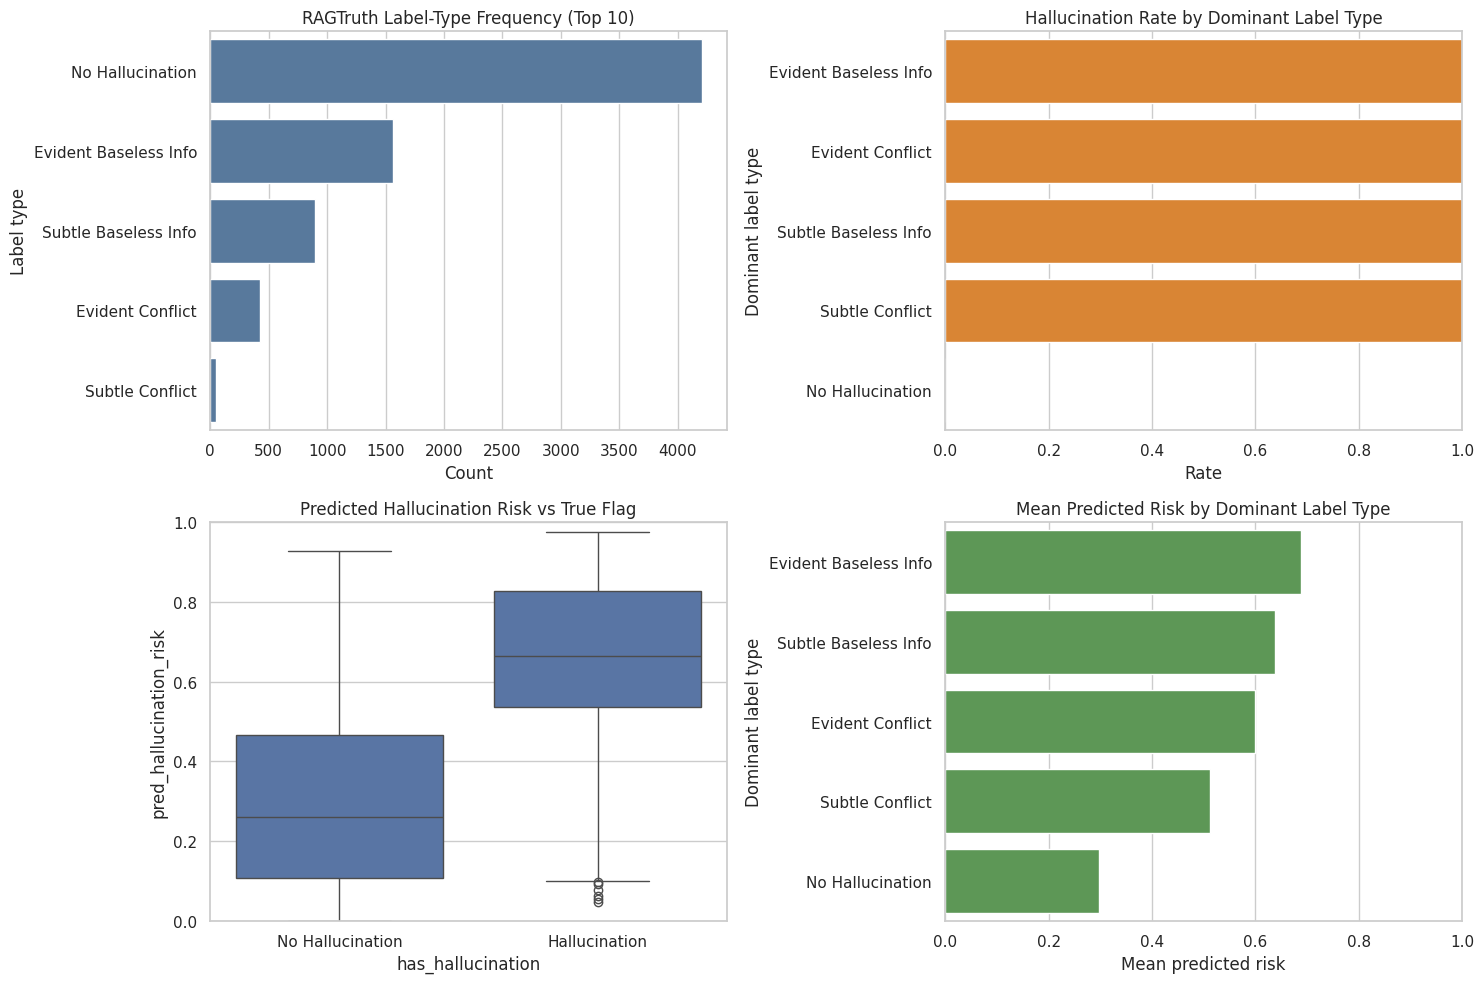

In [24]:
# Cell 23b — RAGTruth Label Integration + Visualization

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter

sns.set(style="whitegrid")

if "ragtruth_qa" not in globals() or len(ragtruth_qa) == 0:
    print("ragtruth_qa is empty. Run the RAGTruth loading cell first.")
else:
    rt = ragtruth_qa.copy()

    # Ensure binary hallucination flag exists
    if "has_hallucination" not in rt.columns:
        rt["has_hallucination"] = rt["labels"].apply(lambda x: isinstance(x, list) and len(x) > 0)

    # Extract label types from span labels
    def extract_label_types(labels):
        out = []
        if isinstance(labels, list):
            for lab in labels:
                if isinstance(lab, dict):
                    out.append(lab.get("label_type", "unknown"))
        return out

    def dominant_type(types):
        if not types:
            return "No Hallucination"
        return Counter(types).most_common(1)[0][0]

    rt["label_types"] = rt["labels"].apply(extract_label_types)
    rt["num_labels"] = rt["label_types"].apply(len)
    rt["dominant_label_type"] = rt["label_types"].apply(dominant_type)

    # Integrate hallucination-risk model predictions (if model is available)
    if "hallucination_clf" in globals() and hallucination_clf is not None:
        if "context_text" not in rt.columns:
            rt["context_text"] = rt["source_info"].apply(source_info_to_text)

        H_rt = pd.DataFrame([
            hallucination_features(c, r)
            for c, r in zip(rt["context_text"], rt["response"])
        ])
        rt["pred_hallucination_risk"] = hallucination_clf.predict_proba(H_rt)[:, 1]
    else:
        rt["pred_hallucination_risk"] = np.nan

    # Exploded frame for label-frequency view
    exp = rt[["has_hallucination", "label_types", "pred_hallucination_risk"]].explode("label_types")
    exp["label_types"] = exp["label_types"].fillna("No Hallucination")

    # ---- Metrics summary ----
    print("RAGTruth QA rows:", len(rt))
    print("Hallucination prevalence:", round(float(rt["has_hallucination"].mean()), 4))
    print("\nTop label types:")
    display(exp["label_types"].value_counts().head(10))

    # ---- Visualization ----
    fig, ax = plt.subplots(2, 2, figsize=(15, 10))

    # 1) Label-type frequency
    top_types = exp["label_types"].value_counts().head(10).index
    sns.countplot(
        data=exp[exp["label_types"].isin(top_types)],
        y="label_types",
        order=top_types,
        ax=ax[0, 0],
        color="#4c78a8"
    )
    ax[0, 0].set_title("RAGTruth Label-Type Frequency (Top 10)")
    ax[0, 0].set_xlabel("Count")
    ax[0, 0].set_ylabel("Label type")

    # 2) Hallucination prevalence by dominant label type
    dom_prev = (
        rt.groupby("dominant_label_type")["has_hallucination"]
        .mean()
        .sort_values(ascending=False)
        .head(10)
        .reset_index()
    )
    sns.barplot(data=dom_prev, x="has_hallucination", y="dominant_label_type", ax=ax[0, 1], color="#f58518")
    ax[0, 1].set_title("Hallucination Rate by Dominant Label Type")
    ax[0, 1].set_xlabel("Rate")
    ax[0, 1].set_ylabel("Dominant label type")
    ax[0, 1].set_xlim(0, 1)

    # 3) Predicted risk by true hallucination flag
    if rt["pred_hallucination_risk"].notna().any():
        sns.boxplot(
            data=rt,
            x="has_hallucination",
            y="pred_hallucination_risk",
            ax=ax[1, 0]
        )
        ax[1, 0].set_xticklabels(["No Hallucination", "Hallucination"])
        ax[1, 0].set_title("Predicted Hallucination Risk vs True Flag")
        ax[1, 0].set_ylim(0, 1)
    else:
        ax[1, 0].text(0.5, 0.5, "hallucination_clf not available", ha="center", va="center")
        ax[1, 0].set_axis_off()

    # 4) Predicted risk by dominant label type
    if rt["pred_hallucination_risk"].notna().any():
        risk_by_type = (
            rt.groupby("dominant_label_type")["pred_hallucination_risk"]
            .mean()
            .sort_values(ascending=False)
            .head(10)
            .reset_index()
        )
        sns.barplot(
            data=risk_by_type,
            x="pred_hallucination_risk",
            y="dominant_label_type",
            ax=ax[1, 1],
            color="#54a24b"
        )
        ax[1, 1].set_title("Mean Predicted Risk by Dominant Label Type")
        ax[1, 1].set_xlabel("Mean predicted risk")
        ax[1, 1].set_ylabel("Dominant label type")
        ax[1, 1].set_xlim(0, 1)
    else:
        ax[1, 1].text(0.5, 0.5, "hallucination_clf not available", ha="center", va="center")
        ax[1, 1].set_axis_off()

    plt.tight_layout()
    plt.show()


In [25]:
#Cell 24: Add Hallucination Risk To System Outputs

def estimate_hallucination_risk(answer, retrieved):
    if hallucination_clf is None:
        return np.nan

    context = "\n".join(r["text"] for r in retrieved)
    feats = pd.DataFrame([hallucination_features(context, answer)])
    risk = hallucination_clf.predict_proba(feats)[0, 1]
    return float(risk)

def answerability_aware_rag_with_risk(question, top_k=TOP_K):
    out = answerability_aware_rag(question, top_k=top_k)
    out["hallucination_risk"] = estimate_hallucination_risk(
        out["answer"],
        out["retrieved"]
    )
    return out

example_risk = answerability_aware_rag_with_risk(df.iloc[1]["question"])

print("Decision:", example_risk["decision"])
print("P(answerable):", round(example_risk["prob_answerable"], 3))
print("Hallucination risk:", example_risk["hallucination_risk"])
print("Answer:", example_risk["answer"])

Decision: answer
P(answerable): 0.994
Hallucination risk: 0.12681677079550047
Answer: Unable to answer based on the provided documentation


In [26]:
#Cell 25: Final Single-Question Demo

question = "How do I configure SSL mutual authentication in IBM HTTP Server?"

out = answerability_aware_rag_with_risk(question)

print("QUESTION")
print(out["question"])

print("\nDECISION")
print(out["decision"])

print("\nANSWERABILITY PROBABILITY")
print(round(out["prob_answerable"], 4))

print("\nHALLUCINATION RISK")
print(out["hallucination_risk"])

print("\nANSWER")
print(out["answer"])

print("\nTOP RETRIEVED DOCUMENTS")
for r in out["retrieved"]:
    print(f"- Rank {r['rank']} | {r['filename']} | score={r['hybrid_score']:.3f}")

print("\nUNSUPPORTED CLAIMS")
for claim in out["support"]["unsupported_claims"]:
    print("-", claim)

QUESTION
How do I configure SSL mutual authentication in IBM HTTP Server?

DECISION
request_more_evidence

ANSWERABILITY PROBABILITY
0.4752

HALLUCINATION RISK
0.30991732307817227

ANSWER
The retrieved documentation appears related but not sufficient. Please provide more specific or stronger evidence before answering.

TOP RETRIEVED DOCUMENTS
- Rank 1 | swg21260155.txt | score=0.967
- Rank 2 | swg21179559.txt | score=0.897
- Rank 3 | swg21114864.txt | score=0.869
- Rank 4 | swg21612222.txt | score=0.785
- Rank 5 | swg21979016.txt | score=0.715

UNSUPPORTED CLAIMS


In [27]:
# Cell 26 — Performance metrics matrix (aligned to your notebook pipeline)

import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score, roc_auc_score, precision_recall_fscore_support

# 1) Retrieval recall@K
def retrieval_recall_at_k(split_df, top_k=TOP_K):
    hits = []
    for _, row in tqdm(split_df.iterrows(), total=len(split_df), desc=f"Retrieval recall@{top_k}", leave=False):
        if not bool(row["answerable"]):
            continue

        gold = set()
        for ctx in row["contexts"]:
            if isinstance(ctx, dict) and ctx.get("filename"):
                gold.add(str(ctx["filename"]))
        if not gold:
            continue

        retrieved = retrieve(row["question"], top_k=top_k)
        retrieved_files = set(r["filename"] for r in retrieved)
        hits.append(int(len(gold.intersection(retrieved_files)) > 0))

    return float(np.mean(hits)) if hits else np.nan

val_recall = retrieval_recall_at_k(val_df, top_k=TOP_K)
test_recall = retrieval_recall_at_k(test_df, top_k=TOP_K)

# 2) Answerability classifier metrics
val_prob = answerability_clf.predict_proba(X_val)[:, 1]
test_prob = answerability_clf.predict_proba(X_test)[:, 1]
val_pred = answerability_clf.predict(X_val)
test_pred = answerability_clf.predict(X_test)

val_p, val_r, val_f1, _ = precision_recall_fscore_support(y_val, val_pred, average="binary", zero_division=0)
test_p, test_r, test_f1, _ = precision_recall_fscore_support(y_test, test_pred, average="binary", zero_division=0)

# 3) End-to-end system metrics from test_results
if "test_results" not in globals():
    test_results = evaluate_system(test_df, name="test", max_examples=MAX_EVAL_EXAMPLES)

sys_true = test_results["true_answerable"].astype(int).values
sys_pred = (test_results["decision"] == "answer").astype(int).values

unanswerable_df = test_results[test_results["true_answerable"] == False]
answerable_df = test_results[test_results["true_answerable"] == True]

unsafe_answer_rate = (unanswerable_df["decision"] == "answer").mean() if len(unanswerable_df) else np.nan
false_abstention_rate = (answerable_df["decision"] != "answer").mean() if len(answerable_df) else np.nan

metrics_matrix = pd.DataFrame([
    {"component": f"retrieval@{TOP_K}", "split": "validation", "metric": "recall@k", "value": val_recall},
    {"component": f"retrieval@{TOP_K}", "split": "test",       "metric": "recall@k", "value": test_recall},

    {"component": "answerability_clf", "split": "validation", "metric": "accuracy",  "value": accuracy_score(y_val, val_pred)},
    {"component": "answerability_clf", "split": "validation", "metric": "auroc",     "value": roc_auc_score(y_val, val_prob)},
    {"component": "answerability_clf", "split": "validation", "metric": "precision", "value": val_p},
    {"component": "answerability_clf", "split": "validation", "metric": "recall",    "value": val_r},
    {"component": "answerability_clf", "split": "validation", "metric": "f1",        "value": val_f1},

    {"component": "answerability_clf", "split": "test", "metric": "accuracy",  "value": accuracy_score(y_test, test_pred)},
    {"component": "answerability_clf", "split": "test", "metric": "auroc",     "value": roc_auc_score(y_test, test_prob)},
    {"component": "answerability_clf", "split": "test", "metric": "precision", "value": test_p},
    {"component": "answerability_clf", "split": "test", "metric": "recall",    "value": test_r},
    {"component": "answerability_clf", "split": "test", "metric": "f1",        "value": test_f1},

    {"component": "end_to_end_system", "split": "test", "metric": "decision_accuracy",           "value": accuracy_score(sys_true, sys_pred)},
    {"component": "end_to_end_system", "split": "test", "metric": "unsafe_answer_rate",          "value": unsafe_answer_rate},
    {"component": "end_to_end_system", "split": "test", "metric": "false_abstention_rate",       "value": false_abstention_rate},
    {"component": "end_to_end_system", "split": "test", "metric": "mean_rougeL",                 "value": test_results["rougeL"].mean()},
    {"component": "end_to_end_system", "split": "test", "metric": "mean_unsupported_claim_rate", "value": test_results["unsupported_claim_rate"].mean()},
]).sort_values(["component", "split", "metric"]).reset_index(drop=True)

display(metrics_matrix.style.format({"value": "{:.4f}"}))


Retrieval recall@5:   0%|          | 0/136 [00:00<?, ?it/s]

Retrieval recall@5:   0%|          | 0/137 [00:00<?, ?it/s]

,component,split,metric,value
0,answerability_clf,test,accuracy,0.7372
1,answerability_clf,test,auroc,0.7993
2,answerability_clf,test,f1,0.7931
3,answerability_clf,test,precision,0.8415
4,answerability_clf,test,recall,0.7500
5,answerability_clf,validation,accuracy,0.7721
6,answerability_clf,validation,auroc,0.8322
7,answerability_clf,validation,f1,0.8360
8,answerability_clf,validation,precision,0.8061
9,answerability_clf,validation,recall,0.8681


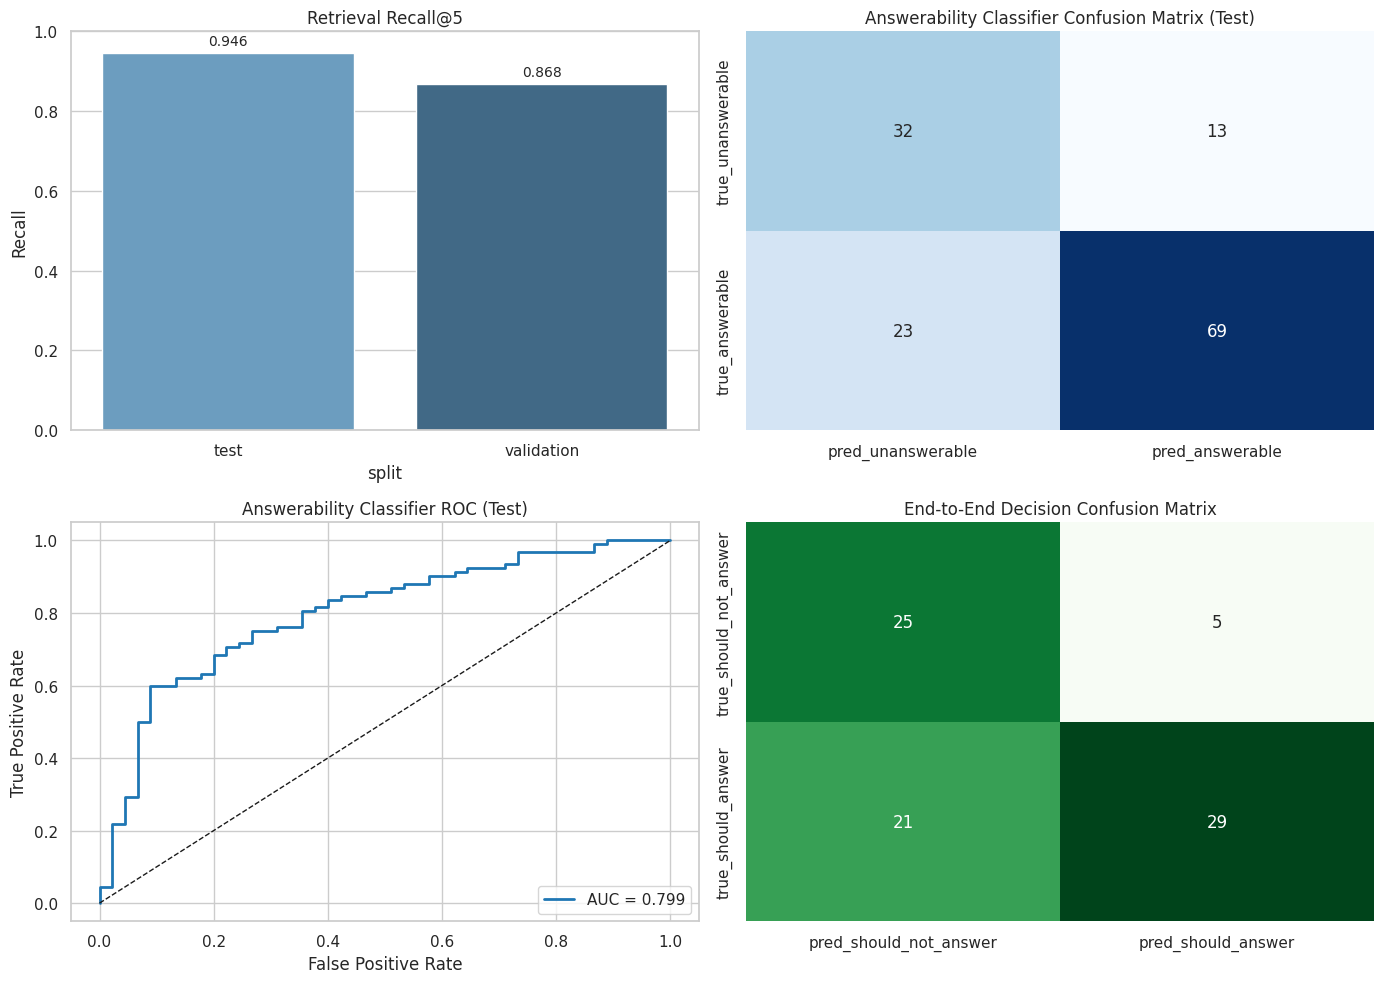

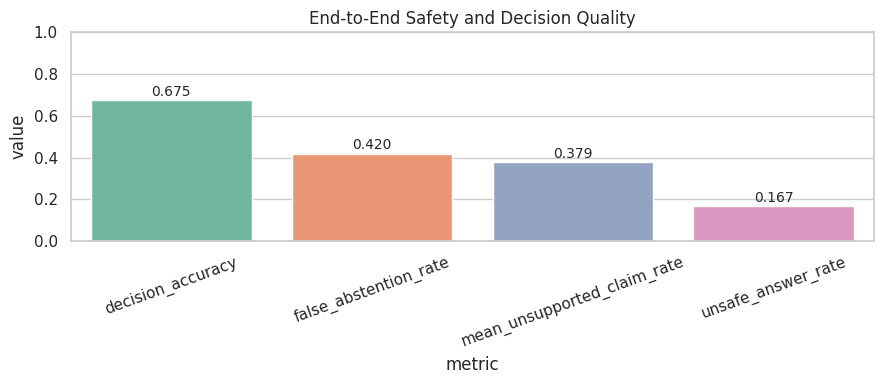

In [28]:
# Cell 27 — Performance visualizations (aligned to same metrics/components)

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

sns.set(style="whitegrid")

# Reuse predictions
val_pred = answerability_clf.predict(X_val)
test_pred = answerability_clf.predict(X_test)
test_prob = answerability_clf.predict_proba(X_test)[:, 1]

# System decision labels
sys_true = test_results["true_answerable"].astype(int).values
sys_pred = (test_results["decision"] == "answer").astype(int).values

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1) Retrieval recall bars
ret_plot = metrics_matrix[
    (metrics_matrix["component"].str.startswith("retrieval")) &
    (metrics_matrix["metric"] == "recall@k")
].copy()
sns.barplot(data=ret_plot, x="split", y="value", ax=axes[0, 0], palette="Blues_d")
axes[0, 0].set_title(f"Retrieval Recall@{TOP_K}")
axes[0, 0].set_ylim(0, 1)
axes[0, 0].set_ylabel("Recall")
for i, v in enumerate(ret_plot["value"].values):
    axes[0, 0].text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=10)

# 2) Answerability classifier confusion matrix (test)
cm_clf = confusion_matrix(y_test, test_pred)
sns.heatmap(
    cm_clf, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0, 1],
    xticklabels=["pred_unanswerable", "pred_answerable"],
    yticklabels=["true_unanswerable", "true_answerable"]
)
axes[0, 1].set_title("Answerability Classifier Confusion Matrix (Test)")
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("")

# 3) ROC curve (test)
fpr, tpr, _ = roc_curve(y_test, test_prob)
roc_auc = auc(fpr, tpr)
axes[1, 0].plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}", color="#1f77b4", linewidth=2)
axes[1, 0].plot([0, 1], [0, 1], "k--", linewidth=1)
axes[1, 0].set_title("Answerability Classifier ROC (Test)")
axes[1, 0].set_xlabel("False Positive Rate")
axes[1, 0].set_ylabel("True Positive Rate")
axes[1, 0].legend(loc="lower right")

# 4) End-to-end decision confusion matrix
cm_sys = confusion_matrix(sys_true, sys_pred)
sns.heatmap(
    cm_sys, annot=True, fmt="d", cmap="Greens", cbar=False, ax=axes[1, 1],
    xticklabels=["pred_should_not_answer", "pred_should_answer"],
    yticklabels=["true_should_not_answer", "true_should_answer"]
)
axes[1, 1].set_title("End-to-End Decision Confusion Matrix")
axes[1, 1].set_xlabel("")
axes[1, 1].set_ylabel("")

plt.tight_layout()
plt.show()

# Optional: compact bar chart for key system rates
key = metrics_matrix[
    (metrics_matrix["component"] == "end_to_end_system") &
    (metrics_matrix["metric"].isin(["decision_accuracy", "unsafe_answer_rate", "false_abstention_rate", "mean_unsupported_claim_rate"]))
].copy()

plt.figure(figsize=(9, 4))
sns.barplot(data=key, x="metric", y="value", palette="Set2")
plt.ylim(0, 1)
plt.title("End-to-End Safety and Decision Quality")
plt.xticks(rotation=20)
for i, v in enumerate(key["value"].values):
    plt.text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=10)
plt.tight_layout()
plt.show()


config.json:   0%|          | 0.00/728 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/557M [00:00<?, ?B/s]

...

  0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

DebertaModel LOAD REPORT from: microsoft/deberta-base-mnli
Key                 | Status     |  | 
--------------------+------------+--+-
pooler.dense.weight | UNEXPECTED |  | 
classifier.bias     | UNEXPECTED |  | 
config              | UNEXPECTED |  | 
pooler.dense.bias   | UNEXPECTED |  | 
classifier.weight   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,id,decision,bertscore_precision,bertscore_recall,bertscore_f1
6,TRAIN_Q517,answer,0.610589,0.523009,0.563416
8,TRAIN_Q297,answer,0.577156,0.487796,0.528727
17,TRAIN_Q438,answer,0.494162,0.471935,0.482793
19,TRAIN_Q056,answer,0.619502,0.526080,0.568982
22,TRAIN_Q466,answer,0.548995,0.458988,0.499973


Mean BERTScore Precision: 0.5574
Mean BERTScore Recall   : 0.4268
Mean BERTScore F1       : 0.4801


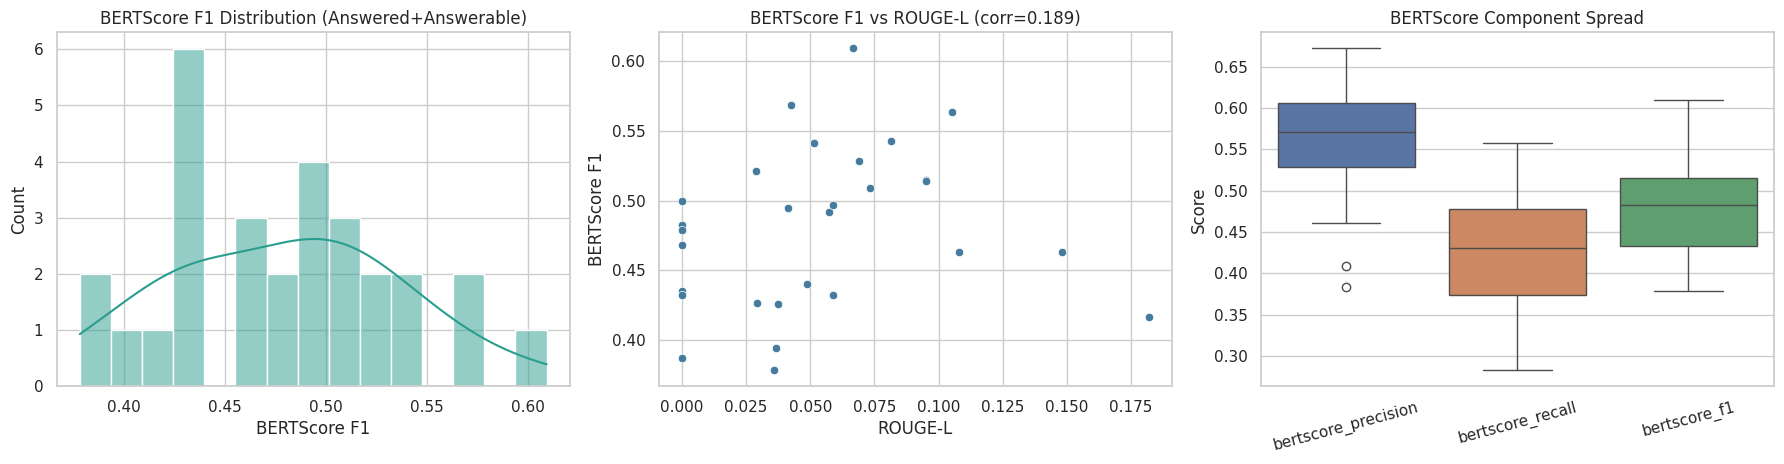

In [29]:
# Cell 28 — Stable BERTScore + appropriate visualization

import os
os.environ["DISABLE_SAFETENSORS_CONVERSION"] = "1"   # suppress HF auto-conversion thread noise

import re
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from bert_score import score as bertscore_score, BERTScorer

sns.set(style="whitegrid")

def _clean_text(x, max_chars=4000):
    x = re.sub(r"\s+", " ", str(x)).strip()
    return x[:max_chars]

# project-appropriate evaluation subset:
# answerable + actually answered by system
bdf = test_results.copy()
bdf = bdf[
    (bdf["true_answerable"] == True) &
    (bdf["decision"] == "answer") &
    bdf["gold_answer"].notna() &
    (bdf["gold_answer"].astype(str).str.strip() != "-")
].copy()

if len(bdf) == 0:
    print("No valid rows for BERTScore after filtering (answerable + decision=='answer').")
else:
    cands = [_clean_text(x) for x in bdf["generated_answer"].fillna("").tolist()]
    refs  = [_clean_text(x) for x in bdf["gold_answer"].tolist()]

    try:
        P, R, F1 = bertscore_score(
            cands, refs,
            model_type="microsoft/deberta-base-mnli",
            lang="en",
            rescale_with_baseline=False,     # keep scores in intuitive range
            use_fast_tokenizer=False,
            batch_size=8,
            verbose=True
        )
    except OverflowError:
        scorer = BERTScorer(
            model_type="microsoft/deberta-base-mnli",
            lang="en",
            rescale_with_baseline=False,
            use_fast_tokenizer=False,
            batch_size=8,
            device="cuda" if torch.cuda.is_available() else "cpu"
        )
        if hasattr(scorer, "_tokenizer") and getattr(scorer._tokenizer, "model_max_length", 0) > 100000:
            scorer._tokenizer.model_max_length = 512
        P, R, F1 = scorer.score(cands, refs)
        
    bdf["bertscore_precision"] = P.cpu().numpy()
    bdf["bertscore_recall"] = R.cpu().numpy()
    bdf["bertscore_f1"] = F1.cpu().numpy()

    display(bdf[["id", "decision", "bertscore_precision", "bertscore_recall", "bertscore_f1"]].head())

    print("Mean BERTScore Precision:", round(float(bdf["bertscore_precision"].mean()), 4))
    print("Mean BERTScore Recall   :", round(float(bdf["bertscore_recall"].mean()), 4))
    print("Mean BERTScore F1       :", round(float(bdf["bertscore_f1"].mean()), 4))

    # Visualization
    fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))

    sns.histplot(bdf["bertscore_f1"], bins=15, kde=True, color="#2a9d8f", ax=axes[0])
    axes[0].set_title("BERTScore F1 Distribution (Answered+Answerable)")
    axes[0].set_xlabel("BERTScore F1")

    sns.scatterplot(data=bdf, x="rougeL", y="bertscore_f1", ax=axes[1], color="#457b9d")
    corr = bdf[["rougeL", "bertscore_f1"]].dropna().corr().iloc[0, 1] if bdf["rougeL"].notna().any() else np.nan
    axes[1].set_title(f"BERTScore F1 vs ROUGE-L (corr={corr:.3f})" if not np.isnan(corr) else "BERTScore F1 vs ROUGE-L")
    axes[1].set_xlabel("ROUGE-L")
    axes[1].set_ylabel("BERTScore F1")

    sns.boxplot(data=bdf[["bertscore_precision", "bertscore_recall", "bertscore_f1"]], ax=axes[2])
    axes[2].set_title("BERTScore Component Spread")
    axes[2].set_ylabel("Score")
    axes[2].tick_params(axis="x", rotation=15)

    plt.tight_layout()
    plt.show()


LLM judge:   0%|          | 0/40 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Parsed complete rows: 40/40 (100.0%)

Per-dimension parse rate:
decision_appropriateness    1.0
factuality                  1.0
completeness                1.0
overall                     1.0
dtype: float64

Mean scores (on available parsed values):
decision_appropriateness    4.80
factuality                  4.65
completeness                4.80
overall                     4.75
dtype: float64


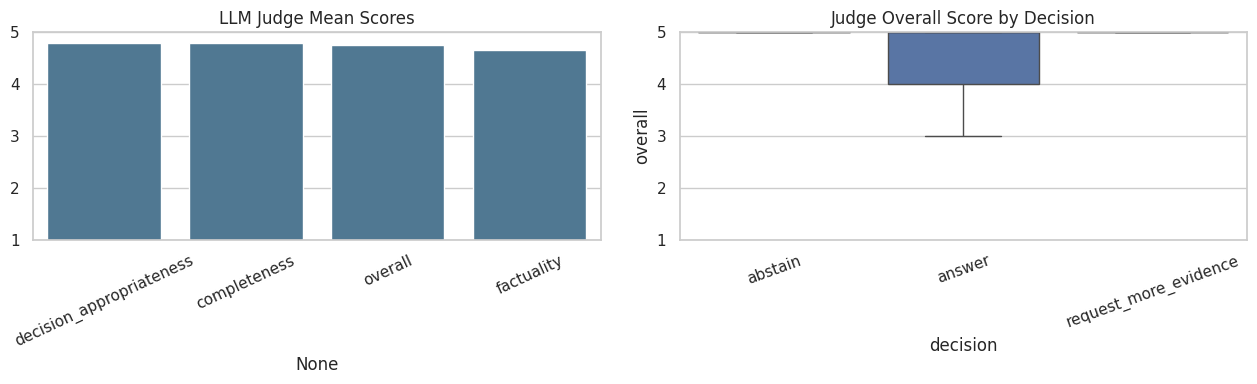

In [30]:
# Cell 29 — LLM Judge Evaluation + Visualization (robust + fixed)

import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
from tqdm.auto import tqdm

sns.set(style="whitegrid")

JUDGE_N = min(40, len(test_results))
judge_df = test_results.sample(n=JUDGE_N, random_state=SEED).reset_index(drop=True).copy()

GRADE_TO_SCORE = {"A": 5, "B": 4, "C": 3, "D": 2, "E": 1}

DIMENSIONS = {
    "decision_appropriateness": (
        "Was the action/decision appropriate? "
        "If question is unanswerable, abstain/request_more_evidence should score high. "
        "If answerable, answering should score high."
    ),
    "factuality": "How factually correct is the system answer vs reference/context?",
    "completeness": "How completely does the system answer address the question?",
    "overall": "Overall quality considering decision, factuality, and completeness."
}

def _clip(x, n=700):
    return re.sub(r"\s+", " ", str(x)).strip()[:n]

@torch.inference_mode()
def _generate(text, max_new_tokens=20):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512)
    device = next(gen_model.parameters()).device
    inputs = {k: v.to(device) for k, v in inputs.items()}

    out = gen_model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        num_beams=1,
        do_sample=False,
        temperature=0.0
    )

    decoded = tokenizer.decode(out[0], skip_special_tokens=True)

    # 🔥 IMPORTANT: Remove prompt echo
    return decoded.replace(text, "").strip()

def _extract_score(raw_text):
    t = str(raw_text).strip().upper()

    # ✅ XML tag
    m = re.search(r"<SCORE>\s*([ABCDE])\s*</SCORE>", t)
    if m:
        return GRADE_TO_SCORE[m.group(1)]

    # ✅ "Score: B"
    m = re.search(r"SCORE[:\s\-]*([ABCDE])", t)
    if m:
        return GRADE_TO_SCORE[m.group(1)]

    # ✅ standalone grade anywhere
    m = re.search(r"\b([ABCDE])\b", t)
    if m:
        return GRADE_TO_SCORE[m.group(1)]

    # ✅ numeric anywhere
    m = re.search(r"\b([1-5])\b", t)
    if m:
        return int(m.group(1))

    return np.nan

def _judge_dimension(question, gold_answer, system_answer, true_answerable, dim_name, dim_desc):
    ref = gold_answer if true_answerable else "N/A (unanswerable question)"

    prompt = f"""
You are a strict evaluator.

Criterion: {dim_name}
Definition: {dim_desc}

Question answerable: {true_answerable}

System answer:
{_clip(system_answer, 400)}

Reference:
{_clip(ref, 400)}

Grade using ONLY one letter: A, B, C, D, or E

Output:
<score>X</score>
""".strip()

    txt = _generate(prompt, max_new_tokens=20)
    score = _extract_score(txt)

    # 🔁 Retry if failed
    if np.isnan(score):
        retry_prompt = f"""
Grade with ONE letter only.

A=best, E=worst.

Answer:
{_clip(system_answer, 300)}

Return ONLY:
<score>X</score>
""".strip()

        txt2 = _generate(retry_prompt, max_new_tokens=10)
        score = _extract_score(txt2)

        # 🔥 Final fallback (NEVER return None)
        if np.isnan(score):
            return 3, txt2  # neutral score

        return score, txt2

    # ✅ Always return something
    return score, txt

def llm_judge_once(row):
    out = {}
    for dim, desc in DIMENSIONS.items():
        score, raw = _judge_dimension(
            row["question"], row["gold_answer"], row["generated_answer"], bool(row["true_answerable"]),
            dim, desc
        )
        out[dim] = score
        out[f"raw_{dim}"] = raw
    return out

# Run judge
rows = []
for _, r in tqdm(judge_df.iterrows(), total=len(judge_df), desc="LLM judge"):
    rows.append(llm_judge_once(r))

score_df = pd.concat([judge_df, pd.DataFrame(rows)], axis=1)
cols = ["decision_appropriateness", "factuality", "completeness", "overall"]
for c in cols:
    score_df[c] = pd.to_numeric(score_df[c], errors="coerce")

# Parse diagnostics
score_df["all_parsed"] = score_df[cols].notna().all(axis=1)
parse_rate = score_df["all_parsed"].mean()
print(f"Parsed complete rows: {score_df['all_parsed'].sum()}/{len(score_df)} ({parse_rate:.1%})")
print("\nPer-dimension parse rate:")
print(score_df[cols].notna().mean().round(3))
print("\nMean scores (on available parsed values):")
print(score_df[cols].mean().round(3))

# Visualization (safe even with missing data)
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

mean_scores = score_df[cols].mean().dropna().sort_values(ascending=False)
if len(mean_scores):
    sns.barplot(x=mean_scores.index, y=mean_scores.values, ax=ax[0], color="#457b9d")
    ax[0].set_ylim(1, 5)
    ax[0].set_title("LLM Judge Mean Scores")
    ax[0].tick_params(axis="x", rotation=25)
else:
    ax[0].text(0.5, 0.5, "No parsable judge scores", ha="center", va="center")
    ax[0].set_axis_off()

box_df = score_df.dropna(subset=["overall"]).copy()
if len(box_df):
    sns.boxplot(data=box_df, x="decision", y="overall", ax=ax[1])
    ax[1].set_ylim(1, 5)
    ax[1].set_title("Judge Overall Score by Decision")
    ax[1].tick_params(axis="x", rotation=20)
else:
    ax[1].text(0.5, 0.5, "No valid overall scores to plot", ha="center", va="center")
    ax[1].set_axis_off()

plt.tight_layout()
plt.show()

# Optional debug if parse rate still low:
# display(score_df[[c for c in score_df.columns if c.startswith("raw_")]].head(10))


Raw Brier: 0.1733 | Raw ECE: 0.0993
Calibrated Brier: 0.1722 | Calibrated ECE: 0.0939


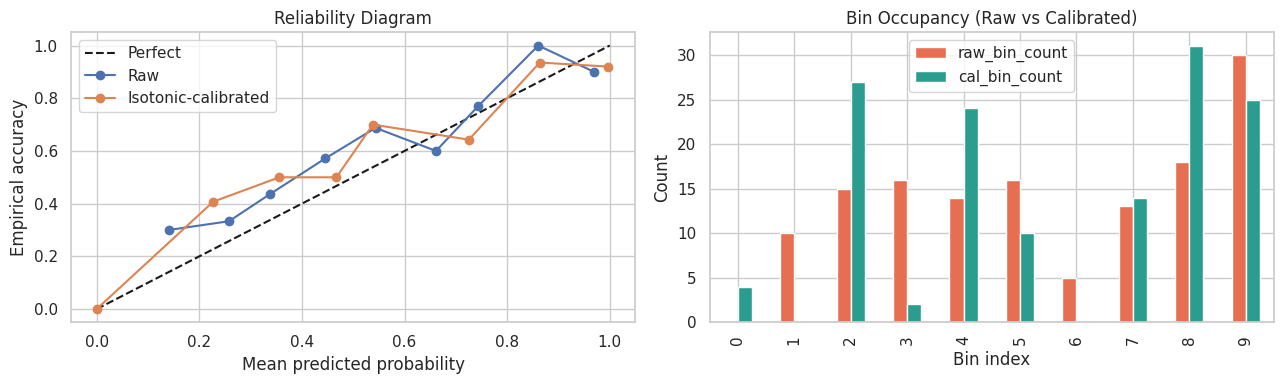

In [31]:
# Cell 30 — Uncertainty Calibration (with isotonic post-hoc calibration) + Visualization
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import brier_score_loss

val_prob = answerability_clf.predict_proba(X_val)[:, 1]
test_prob_raw = answerability_clf.predict_proba(X_test)[:, 1]
y_true = y_test.astype(int)

iso = IsotonicRegression(out_of_bounds="clip")
iso.fit(val_prob, y_val)
test_prob_cal = iso.transform(test_prob_raw)

def calibration_table(y, p, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    idx = np.digitize(p, bins) - 1
    idx = np.clip(idx, 0, n_bins - 1)
    rows, ece = [], 0.0
    for b in range(n_bins):
        m = idx == b
        if m.sum() == 0:
            continue
        conf = p[m].mean()
        acc = y[m].mean()
        gap = abs(acc - conf)
        ece += (m.sum() / len(y)) * gap
        rows.append({"bin": b, "n": m.sum(), "confidence": conf, "accuracy": acc, "gap": gap})
    return pd.DataFrame(rows), ece

raw_tab, ece_raw = calibration_table(y_true, test_prob_raw, n_bins=10)
cal_tab, ece_cal = calibration_table(y_true, test_prob_cal, n_bins=10)

print(f"Raw Brier: {brier_score_loss(y_true, test_prob_raw):.4f} | Raw ECE: {ece_raw:.4f}")
print(f"Calibrated Brier: {brier_score_loss(y_true, test_prob_cal):.4f} | Calibrated ECE: {ece_cal:.4f}")

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot([0, 1], [0, 1], "k--", label="Perfect")
ax[0].plot(raw_tab["confidence"], raw_tab["accuracy"], marker="o", label="Raw")
ax[0].plot(cal_tab["confidence"], cal_tab["accuracy"], marker="o", label="Isotonic-calibrated")
ax[0].set_title("Reliability Diagram")
ax[0].set_xlabel("Mean predicted probability")
ax[0].set_ylabel("Empirical accuracy")
ax[0].legend()

counts_df = pd.DataFrame({
    "raw_bin_count": raw_tab.set_index("bin")["n"],
    "cal_bin_count": cal_tab.set_index("bin")["n"]
}).fillna(0)
counts_df.plot(kind="bar", ax=ax[1], color=["#e76f51", "#2a9d8f"])
ax[1].set_title("Bin Occupancy (Raw vs Calibrated)")
ax[1].set_xlabel("Bin index")
ax[1].set_ylabel("Count")
plt.tight_layout()
plt.show()


Ablation: Full policy (0.60/0.40):   0%|          | 0/30 [00:00<?, ?it/s]

Ablation: Conservative gate (0.70/0.50):   0%|          | 0/30 [00:00<?, ?it/s]

Ablation: Aggressive gate (0.50/0.30):   0%|          | 0/30 [00:00<?, ?it/s]

Ablation: Binary gate (answer/abstain):   0%|          | 0/30 [00:00<?, ?it/s]

Ablation: No gate (always answer):   0%|          | 0/30 [00:00<?, ?it/s]

,variant,decision_accuracy,unsafe_answer_rate,false_abstention_rate,mean_rougeL,mean_unsupported_claim_rate
0,Full policy (0.60/0.40),0.5667,0.2,0.55,0.0295,0.3333
1,Conservative gate (0.70/0.50),0.5667,0.2,0.55,0.0295,0.3333
2,Aggressive gate (0.50/0.30),0.6333,0.2,0.45,0.0273,0.4000
3,Binary gate (answer/abstain),0.5667,0.2,0.55,0.0295,0.3333
4,No gate (always answer),0.6667,1.0,0.00,0.0321,0.9333


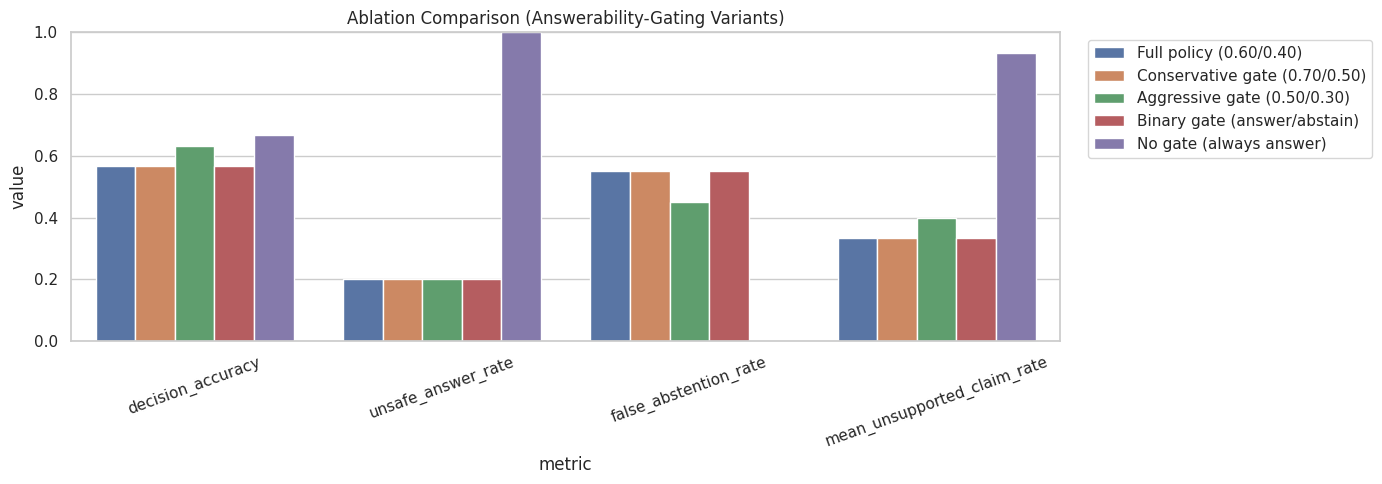

In [32]:
# Cell 31 — Ablation Study + Visualization (focus: answerability gating policy)
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
from tqdm.auto import tqdm

ABLATION_N = min(30, len(test_df))  # increase for full run
ablation_sample = test_df.sample(n=ABLATION_N, random_state=SEED).reset_index(drop=True)

def run_policy(question, ans_thr=ANSWER_THRESHOLD, req_thr=REQUEST_MORE_EVIDENCE_THRESHOLD, force_answer=False, binary_gate=False):
    retrieved = retrieve(question, top_k=TOP_K)
    p, _ = predict_answerability(question)

    if force_answer:
        decision = "answer"
    elif binary_gate:
        decision = "answer" if p >= ans_thr else "abstain"
    else:
        decision = "answer" if p >= ans_thr else ("request_more_evidence" if p >= req_thr else "abstain")

    if decision == "answer":
        answer = generate_answer(question, retrieved)
        support = claim_support_analysis(answer, retrieved)
    elif decision == "request_more_evidence":
        answer = "The retrieved documentation appears related but not sufficient. Please provide more specific or stronger evidence before answering."
        support = {"unsupported_rate": 0.0, "num_claims": 0}
    else:
        answer = "Unable to answer based on the provided documentation."
        support = {"unsupported_rate": 0.0, "num_claims": 0}

    return {"decision": decision, "answer": answer, "prob": p, "support": support}

def evaluate_variant(name, runner, df_eval):
    rows = []
    for _, row in tqdm(df_eval.iterrows(), total=len(df_eval), desc=f"Ablation: {name}"):
        out = runner(row["question"])
        answered = out["decision"] == "answer"
        true_ans = bool(row["answerable"])
        r = rouge_l(out["answer"], row["answer"]) if (true_ans and answered) else np.nan
        rows.append({"true_answerable": true_ans, "decision": out["decision"], "rougeL": r, "unsupported": out["support"]["unsupported_rate"]})
    res = pd.DataFrame(rows)
    unans = res[res["true_answerable"] == False]
    ans = res[res["true_answerable"] == True]
    return {
        "variant": name,
        "decision_accuracy": ((res["decision"] == "answer").astype(int).eq(res["true_answerable"].astype(int))).mean(),
        "unsafe_answer_rate": (unans["decision"] == "answer").mean() if len(unans) else np.nan,
        "false_abstention_rate": (ans["decision"] != "answer").mean() if len(ans) else np.nan,
        "mean_rougeL": res["rougeL"].mean(),
        "mean_unsupported_claim_rate": res["unsupported"].mean()
    }

variants = {
    "Full policy (0.60/0.40)": lambda q: run_policy(q, 0.60, 0.40),
    "Conservative gate (0.70/0.50)": lambda q: run_policy(q, 0.70, 0.50),
    "Aggressive gate (0.50/0.30)": lambda q: run_policy(q, 0.50, 0.30),
    "Binary gate (answer/abstain)": lambda q: run_policy(q, 0.60, 0.40, binary_gate=True),
    "No gate (always answer)": lambda q: run_policy(q, force_answer=True),
}

ablation_rows = [evaluate_variant(name, fn, ablation_sample) for name, fn in variants.items()]
ablation_df = pd.DataFrame(ablation_rows)
display(ablation_df.round(4))

plot_df = ablation_df.melt(
    id_vars="variant",
    value_vars=["decision_accuracy", "unsafe_answer_rate", "false_abstention_rate", "mean_unsupported_claim_rate"],
    var_name="metric", value_name="value"
)
plt.figure(figsize=(14, 5))
sns.barplot(data=plot_df, x="metric", y="value", hue="variant")
plt.title("Ablation Comparison (Answerability-Gating Variants)")
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()
